# Task 7: Coin Detection and Counting using Hough Circles

**Lab 06 solution**  
Run cells from top to bottom. Change only the paths in the configuration cell when using your own media.

In [6]:
# Install once if required:
# !pip install opencv-contrib-python numpy matplotlib PyWavelets
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def show(img, title='', cmap=None, size=(12,7)):
    plt.figure(figsize=size)
    if img.ndim == 3:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap or 'gray')
    plt.title(title); plt.axis('off'); plt.show()

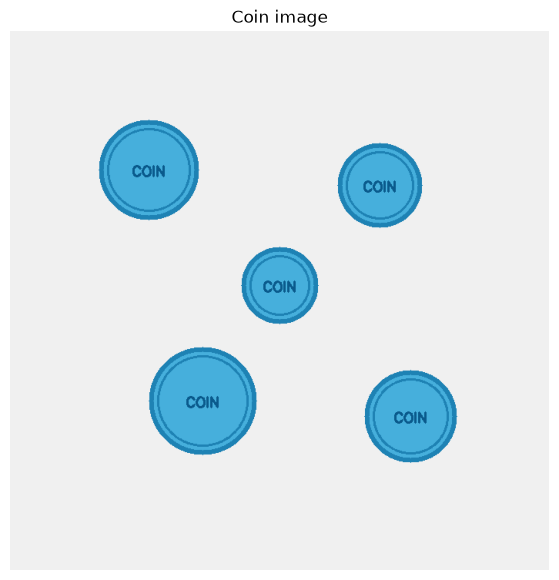

In [7]:
# ============================================================
# Load and Preprocess Coin Image
# ============================================================

IMAGE_PATH = 'coin.png'


# ============================================================
# Load Image
# ============================================================

img = cv.imread(
    IMAGE_PATH
)


# ============================================================
# Validate Image
# ============================================================

if img is None:

    raise FileNotFoundError(
        f"Image not found: {IMAGE_PATH}"
    )


# ============================================================
# Convert to Grayscale and Reduce Noise
# ============================================================

gray = cv.cvtColor(
    img,
    cv.COLOR_BGR2GRAY
)

gray = cv.medianBlur(
    gray,
    7
)


# ============================================================
# Display Input Image
# ============================================================

show(
    img,
    'Coin image'
)


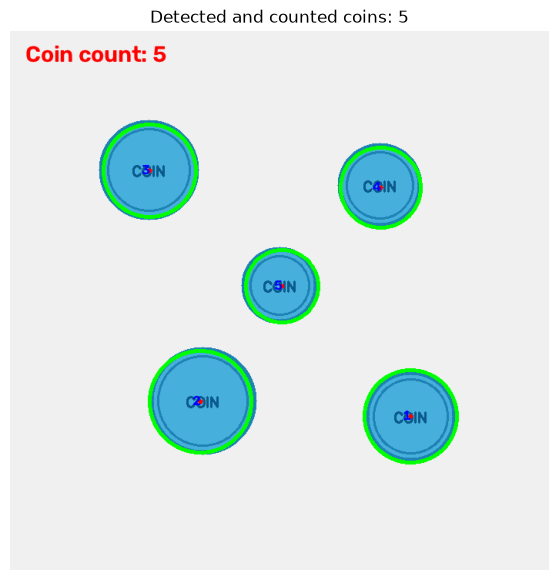

Total coins: 5


In [8]:
# ============================================================
# Detect and Count Coins using Hough Circles
# ============================================================

# Tune minRadius and maxRadius according to image scale.
# param2 controls how strict the circle detection is.

circles = cv.HoughCircles(
    gray,
    cv.HOUGH_GRADIENT,
    dp=1.2,
    minDist=35,
    param1=120,
    param2=30,
    minRadius=15,
    maxRadius=100
)


# ============================================================
# Prepare Result
# ============================================================

result = img.copy()
count = 0


# ============================================================
# Process Detected Circles
# ============================================================

if circles is not None:

    circles = np.uint16(
        np.around(
            circles[0]
        )
    )

    count = len(circles)

    for i, (x, y, r) in enumerate(
        circles,
        start=1
    ):

        # Draw detected coin boundary
        cv.circle(
            result,
            (x, y),
            r,
            (0, 255, 0),
            3
        )

        # Draw center point
        cv.circle(
            result,
            (x, y),
            3,
            (0, 0, 255),
            -1
        )

        # Add coin number
        cv.putText(
            result,
            str(i),
            (x - 10, y + 5),
            cv.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )


# ============================================================
# Display Coin Count
# ============================================================

cv.putText(
    result,
    f'Coin count: {count}',
    (20, 40),
    cv.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 0, 255),
    3
)


# ============================================================
# Display and Save Result
# ============================================================

show(
    result,
    f'Detected and counted coins: {count}'
)

cv.imwrite(
    'task7_coin_count.jpg',
    result
)


# ============================================================
# Print Final Count
# ============================================================

print(
    'Total coins:',
    count
)


## Parameter effects
`minDist` prevents duplicate circles for one coin. `param1` controls the internal Canny high threshold. Lower `param2` detects more circles but raises false positives. Radius limits exclude objects outside the expected coin scale.